In [1]:
import sys
import os
from TopoAnalysis import dem as d
import numpy as np
import matplotlib.pyplot as plt

In [2]:
"""
Rapel River Fluvial Landform Inversion Workflow

This notebook processes the Rapel DEM and runs fluvial inversion to reconstruct
uplift rate history for sample locations.

Working from: AndesTG/Rapel/base_level/LGoren_Fluvial_landform_inversion.ipynb
"""

# Add FluvialLandformInversion to path
sys.path.insert(0, '/Users/Glong1/Desktop/Andes/AndesTG/FluvialLandformInversion_master/python')

from fluvial_inversion import (
    prepare_inversion_data, 
    findm_slope_area, 
    calculate_chi, 
    invert_block_uplift,
    invert_with_different_gamma,
    calibrate_k_total_uplift,
    bootstrap_invert_block_uplift
)

In [6]:
print(dem._georef_info.xllcenter, dem._georef_info.yllcenter)

125032.2717442584 6046054.072526088


In [13]:
# Load and process DEM
dem = d.Elevation.load('/Users/Glong1/Desktop/Andes/Andes_watersheds/RapelRiver/BaseLevel/rapel_SRTMGL130m_dem_utm_clipped.tif')
print('dem loaded')
filled_dem = d.FilledElevation(elevation=dem)
print('finished filling')
flow_dir = d.FlowDirectionD8(flooded_dem=filled_dem)
print('finished flooding')
area_grid = d.Area(flow_direction=flow_dir)
print('finished flow direction')

dem loaded
finished filling
finished flooding
finished flow direction


In [14]:
# Check DEM stats first
import numpy as np

print(f"DEM shape: {dem._griddata.shape}")
print(f"Total pixels: {dem._griddata.size:,}")
print(f"Area grid max: {np.nanmax(area_grid._griddata):,.0f} m²")
print(f"Pixels above 1km² threshold: {np.sum(area_grid._griddata >= min_area):,}")

DEM shape: (1357, 1656)
Total pixels: 2,247,192
Area grid max: 487,615,665 m²
Pixels above 1km² threshold: 37,963


In [15]:
# Extract fluvial network
outlet = (250212.9354, 6237948.848) # RP-S3, change to whichever you are looking at
min_area = 1e6 # 1km^2 

data = prepare_inversion_data(
    dem=filled_dem,
    area=area_grid,
    flow_direction=flow_dir,
    outlet_location=outlet,
    min_drainage_area=min_area
)

In [24]:
# Run the inversion
chi = calculate_chi(data['x'], data['y'], data['rec_array'], data['area_array'], m=0.45)
Ustar, tstar, misfit = invert_block_uplift(chi, data['z'], gamma=1.0, q=10)

Network stats:
  Data pixels: 37,909
  Elevation shape: (37909,)
  Chi shape: (37909,)
  Ustar shape: (10,)
  tstar shape: (11,)
  Misfit: 0.3515


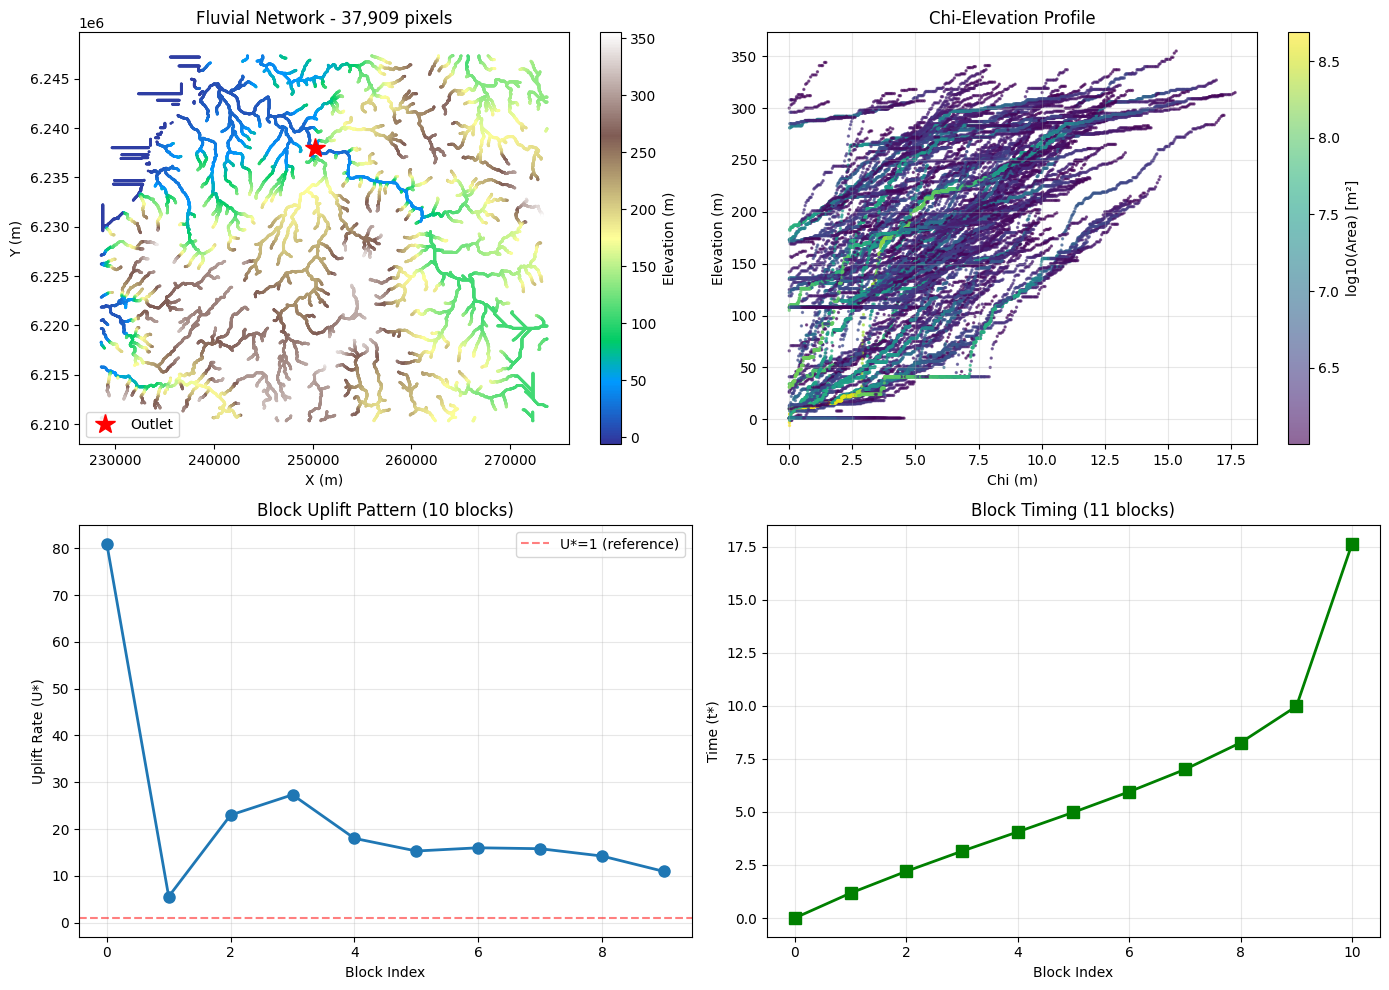


Uplift blocks:
  Block 0: U* = 81.009, t* = 0.000
  Block 1: U* = 5.581, t* = 1.175
  Block 2: U* = 22.996, t* = 2.201
  Block 3: U* = 27.331, t* = 3.152
  Block 4: U* = 18.012, t* = 4.061
  Block 5: U* = 15.315, t* = 4.987
  Block 6: U* = 16.003, t* = 5.955
  Block 7: U* = 15.805, t* = 7.006
  Block 8: U* = 14.235, t* = 8.271
  Block 9: U* = 10.945, t* = 9.983


In [21]:
# Visualize

# Check dimensions
print(f"Network stats:")
print(f"  Data pixels: {data['n_pixels']:,}")
print(f"  Elevation shape: {data['z'].shape}")
print(f"  Chi shape: {chi.shape}")
print(f"  Ustar shape: {Ustar.shape}")
print(f"  tstar shape: {tstar.shape}")
print(f"  Misfit: {misfit:.4f}")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Map view of network colored by elevation
ax = axes[0, 0]
scatter = ax.scatter(data['x'], data['y'], c=data['z'], s=1, cmap='terrain')
plt.colorbar(scatter, ax=ax, label='Elevation (m)')
ax.plot(outlet[0], outlet[1], 'r*', markersize=15, label='Outlet')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title(f'Fluvial Network - {data["n_pixels"]:,} pixels')
ax.legend()
ax.axis('equal')

# 2. Chi-Elevation plot
ax = axes[0, 1]
scatter = ax.scatter(chi, data['z'], c=np.log10(data['area_array']), 
                     s=2, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, ax=ax, label='log10(Area) [m²]')
ax.set_xlabel('Chi (m)')
ax.set_ylabel('Elevation (m)')
ax.set_title('Chi-Elevation Profile')
ax.grid(True, alpha=0.3)

# 3. Uplift blocks (if Ustar is shorter than data)
ax = axes[1, 0]
if len(Ustar) < len(data['z']):
    # Plot as step function
    ax.plot(range(len(Ustar)), Ustar, 'o-', linewidth=2, markersize=8)
    ax.set_xlabel('Block Index')
    ax.set_ylabel('Uplift Rate (U*)')
    ax.set_title(f'Block Uplift Pattern ({len(Ustar)} blocks)')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1.0, color='r', linestyle='--', alpha=0.5, label='U*=1 (reference)')
    ax.legend()
else:
    # Full resolution
    scatter = ax.scatter(data['x'], data['y'], c=Ustar, s=1, cmap='RdBu_r')
    plt.colorbar(scatter, ax=ax, label='Uplift Rate (U*)')
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_title('Uplift Pattern')
    ax.axis('equal')

# 4. Time blocks
ax = axes[1, 1]
if len(tstar) < len(data['z']):
    ax.plot(range(len(tstar)), tstar, 's-', linewidth=2, markersize=8, color='green')
    ax.set_xlabel('Block Index')
    ax.set_ylabel('Time (t*)')
    ax.set_title(f'Block Timing ({len(tstar)} blocks)')
    ax.grid(True, alpha=0.3)
else:
    scatter = ax.scatter(chi, Ustar, c=data['z'], s=2, cmap='terrain', alpha=0.6)
    plt.colorbar(scatter, ax=ax, label='Elevation (m)')
    ax.set_xlabel('Chi (m)')
    ax.set_ylabel('Uplift Rate (U*)')
    ax.set_title('Uplift vs Chi')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print uplift results
print(f"\nUplift blocks:")
for i, (u, t) in enumerate(zip(Ustar, tstar)):
    print(f"  Block {i}: U* = {u:.3f}, t* = {t:.3f}")